# Лабораторная работа 1 - Audio Inspection: Waveform, Spectrogram, MFCC

Курс «Автоматическое распознавание речи», ИТМО, 2026.

**Идея лабораторной.** Прежде чем разбираться, почему ASR ошибся, нужно *посмотреть на аудио*: тишина, клиппинг, шум, реверберация и неожиданная скорость речи видны в волновой форме и в time-frequency признаках гораздо раньше, чем в тексте расшифровки.

**Что делает этот notebook.**

| Часть | Содержание |
|---|---|
| A | генерируем 5 speech-like файлов, слушаем их, формулируем ожидания |
| B | статистика аудио: длительность, пик, RMS, доля тишины, доля клиппинга |
| C | волновая форма и увеличенный фрагмент (100 мс) |
| D | лог-спектрограмма STFT |
| E | log-Mel-спектрограмма |
| F | MFCC |
| G | сравнение чистого и искажённого аудио, итоговая таблица |
| + | дополнительное задание: анализ собственной записи |

Ответы на вопросы из описания лабораторной (`LAB_01_DESCRIPTION.md`) идут сразу после соответствующих графиков и опираются на **цифры, посчитанные в этом же notebook**. В конце есть ячейка, которая автоматически проверяет, что все количественные утверждения из ответов выполняются.

## 0. Подготовка: импорты, параметры, стиль графиков

Генерацию аудио и базовые функции берём из скриптов лабораторной (`make_lab_audio.py`, `lab_01_audio_inspection.py`), чтобы числа в notebook совпадали с числами базового скрипта. Графики строим здесь же, inline.

In [ ]:
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import librosa
import librosa.display
from IPython.display import Audio, Image, Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)

# Ноутбук лежит в lab_01_ru/, но можно запускать и из корня репозитория.
LAB_DIR = Path.cwd()
if not (LAB_DIR / "scripts").is_dir():
    LAB_DIR = LAB_DIR / "lab_01_ru"
sys.path.insert(0, str(LAB_DIR.parent))

from lab_01_ru.scripts import make_lab_audio as mk
from lab_01_ru.scripts import lab_01_audio_inspection as lab

WAV_DIR = LAB_DIR / "data" / "wav"
OUT_DIR = LAB_DIR / "outputs"

print("Папка лабораторной:", LAB_DIR)
print("librosa", librosa.__version__, "| numpy", np.__version__)

Папка лабораторной: d:\python_projects\ITMO\ASR_course_labs_year2\lab_01_ru
librosa 1.0.0 | numpy 2.5.3


In [ ]:
# Единый стиль графиков: тонкие линии, приглушённая сетка, у каждого файла свой постоянный цвет.
INK, INK2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.dpi": 85, "savefig.dpi": 85, "font.size": 10,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "lines.linewidth": 0.9,
})

# (ключ, имя файла, подпись, цвет)
FILES = [
    ("clean", "clean_speech_like.wav", "clean - чистый", "#2a78d6"),
    ("noisy",  "noisy_speech_like.wav", "noisy - шум (SNR ≈ 8 дБ)", "#eb6834"),
    ("reverberant", "reverberant_speech_like.wav",  "reverberant - реверберация", "#1baf7a"),
    ("clipped", "clipped_speech_like.wav", "clipped - клиппинг", "#eda100"),
    ("speed_perturbed", "speed_perturbed_speech_like.wav", "speed perturbed - ускорение ×1.15", "#e87ba4"),
]
KEYS = [f[0] for f in FILES]
FNAME = {f[0]: f[1] for f in FILES}
LABEL = {f[0]: f[2] for f in FILES}
COLOR = {f[0]: f[3] for f in FILES}
SHORT = {"clean": "clean", "noisy": "noisy", "reverberant": "reverberant",
         "clipped": "clipped", "speed_perturbed": "speed perturbed"}

# Дивергентная схема для разностей: синий ← серый → красный
DIV_CMAP = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])


def md_table(headers, rows):
    # Выводит markdown-таблицу прямо в ячейку.
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join("---" for _ in headers) + "|"]
    lines += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(lines)))

### Параметры признаков (из описания лабораторной)

Речь меняется во времени, поэтому анализируем её **короткими окнами**, а не как один стационарный сигнал.

In [ ]:
sr = lab.SAMPLE_RATE
md_table(
    ["Параметр", "Значение", "Смысл"],
    [
        ["Частота дискретизации", f"{sr} Гц", f"типичный вход для ASR; частоты речи до Найквиста = {sr/2} кГц"],
        ["Длина FFT / окна", f"{lab.N_FFT} отсчётов = {lab.N_FFT / sr * 1000:.0f} мс", f"разрешение по частоте = sr / n_fft = {sr / lab.N_FFT:.0f} Гц на бин"],
        ["Шаг окна (hop)", f"{lab.HOP_LENGTH} отсчётов = {lab.HOP_LENGTH / sr * 1000:.0f} мс", f"≈ {sr / lab.HOP_LENGTH:.0f} фреймов в секунду"],
        ["Mel-полосы", f"{lab.N_MELS} (от {lab.FMIN} до {lab.FMAX} Гц)", "типичный размер признаков нейросетевого ASR"],
        ["Коэффициенты MFCC", f"{lab.N_MFCC}", "компактное кепстральное представление"],
    ],
)

| Параметр | Значение | Смысл |
|---|---|---|
| Частота дискретизации | 16000 Гц | типичный вход для ASR; частоты речи до Найквиста = 8 кГц |
| Длина FFT / окна | 400 отсчётов = 25 мс | разрешение по частоте = sr / n_fft = 40 Гц на бин |
| Шаг окна (hop) | 160 отсчётов = 10 мс | ≈ 100 фреймов в секунду |
| Mel-полосы | 80 (от 20 до 7600 Гц) | типичный размер признаков нейросетевого ASR |
| Коэффициенты MFCC | 13 | компактное кепстральное представление |

---
## Часть A - Сгенерировать и проверить аудиофайлы

Генератор `make_lab_audio.py` детерминирован (`RANDOM_SEED = 7`), поэтому повторный запуск даёт те же файлы. Из одного **чистого speech-like сигнала** (5 voiced-сегментов с вибрато + короткие fricative-like всплески + слабый шумовой пол) получаются четыре искажённые версии:

| Файл | Как получен |
|---|---|
| `clean_speech_like.wav` | исходный синтетический сигнал, 5.2 с |
| `noisy_speech_like.wav` | + белый гауссовский шум с SNR = 8 дБ |
| `reverberant_speech_like.wav` | свёртка с импульсной характеристикой комнаты (затухающая экспонента 0.42 с + 2 ранних отражения) |
| `clipped_speech_like.wav` | усиление ×2.4 и жёсткая обрезка на ±0.34 |
| `speed_perturbed_speech_like.wav` | передискретизация `resample_poly(100, 115)`: ускорение ×1.15 |

In [ ]:
written = mk.generate_lab_audio(WAV_DIR)
lab.analyze_audio_dir(WAV_DIR, OUT_DIR) # скрипт: графики и audio_summary.csv в outputs/

audio = {}
for key in KEYS:
    audio[key], sr_file = lab.load_audio(WAV_DIR / FNAME[key])
    assert sr_file == sr
    print(f"{FNAME[key]:36s} {len(audio[key]):6d} отсчётов, {len(audio[key]) / sr:.3f} с")

clean_speech_like.wav                 83200 отсчётов, 5.200 с
noisy_speech_like.wav                 83200 отсчётов, 5.200 с
reverberant_speech_like.wav           83200 отсчётов, 5.200 с
clipped_speech_like.wav               83200 отсчётов, 5.200 с
speed_perturbed_speech_like.wav       72348 отсчётов, 4.522 с


Послушаем файлы (`normalize=False` - чтобы не выравнивать громкость и сохранить реальные различия):

In [27]:
for key in KEYS:
    display(Markdown(f"**{LABEL[key]}**"))
    display(Audio(audio[key], rate=sr, normalize=False))

**clean — чистый**

**noisy — шум (SNR ≈ 8 дБ)**

**reverberant — реверберация**

**clipped — клиппинг**

**speed perturbed — ускорение ×1.15**

### Ожидания до измерений (вопросы Части A)

1. **Самая высокая RMS-энергия - у `noisy`.** Шум добавляет мощность: при SNR = 8 дБ мощность шума ≈ 16 % от мощности речи, а после сложения файл ещё пик-нормализуется до 0.92 (у clean - 0.78).
2. **Самое заметное искажение формы волны - у `clipped`.** Обрезка вершин меняет форму *каждого периода*; шум же скорее утолщает линию и заполняет паузы, не меняя форму периода.
3. **Самые размытые спектральные переходы - у `reverberant`.** Хвост импульсной характеристики растягивает энергию каждого звука во времени, поэтому границы звуков на спектрограмме плывут.

Проверка этих ожиданий - в Частях B, C, D (итоговая автопроверка - в конце notebook).

---
## Часть B - Статистика аудио

Считаем те же величины, что и `outputs/audio_summary.csv`, функцией `lab.summarize_audio`:

* `duration = N / sr`
* `peak = max|x|`, `RMS = sqrt(mean(x²))`
* **доля тишины** - отсчёты с `|x| < 2 % от пика`
* **доля клиппинга** - отсчёты с `|x| ≥ 0.98 · пик

In [28]:
summary = {key: lab.summarize_audio(FNAME[key], audio[key], sr) for key in KEYS}

# сверка со штатным CSV
import csv
with (OUT_DIR / "audio_summary.csv").open(encoding="utf-8") as f:
    csv_rows = {r["filename"]: r for r in csv.DictReader(f)}
for key in KEYS:
    r = csv_rows[FNAME[key]]
    assert abs(float(r["rms"]) - summary[key]["rms"]) < 1e-9
    assert abs(float(r["clipping_fraction"]) - summary[key]["clipping_fraction"]) < 1e-9
print("Значения совпадают с outputs/audio_summary.csv")

md_table(
    ["Файл", "Длительность", "Пиковая амплитуда", "RMS", "Доля тишины", "Доля клиппинга"],
    [[SHORT[k], f"{summary[k]['duration_s']:.3f} с", f"{summary[k]['peak_amplitude']:.3f}",
      f"{summary[k]['rms']:.4f}", f"{summary[k]['silence_fraction'] * 100:.1f} %",
      f"{summary[k]['clipping_fraction'] * 100:.4f} %"] for k in KEYS],
)

Значения совпадают с outputs/audio_summary.csv


| Файл | Длительность | Пиковая амплитуда | RMS | Доля тишины | Доля клиппинга |
|---|---|---|---|---|---|
| clean | 5.200 с | 0.780 | 0.2502 | 38.9 % | 0.0024 % |
| noisy | 5.200 с | 0.920 | 0.2654 | 7.7 % | 0.0012 % |
| reverberant | 5.200 с | 0.880 | 0.2164 | 38.5 % | 0.0108 % |
| clipped | 5.200 с | 0.340 | 0.2452 | 29.9 % | 46.3798 % |
| speed perturbed | 4.522 с | 0.780 | 0.2502 | 38.9 % | 0.0014 % |

Для объяснений понадобится ещё несколько производных метрик: уровень RMS в dBFS, **crest factor** (пик/RMS: у сильно сжатого/обрезанного сигнала он падает), RMS «пола» в паузе (первые 150 мс - во всех файлах там пауза), доля энергии в полосе 4–8 кГц и спектральный центроид.

In [29]:
def band_share(x, lo, hi):
    # Доля энергии STFT в полосе [lo, hi) Гц.
    S = np.abs(librosa.stft(x, n_fft=lab.N_FFT, hop_length=lab.HOP_LENGTH, win_length=lab.WIN_LENGTH)) ** 2
    f = librosa.fft_frequencies(sr=sr, n_fft=lab.N_FFT)
    return float(S[(f >= lo) & (f < hi)].sum() / S.sum())


def rms(x):
    return float(np.sqrt(np.mean(np.square(x))))


metrics = {}
for key in KEYS:
    x, s = audio[key], summary[key]
    metrics[key] = {
        "rms_dbfs": 20 * np.log10(s["rms"]),
        "crest": s["peak_amplitude"] / s["rms"],
        "floor_rms": rms(x[: int(0.15 * sr)]),
        "hf_share": band_share(x, 4000, 8000),
        "centroid": float(librosa.feature.spectral_centroid(
            y=x, sr=sr, n_fft=lab.N_FFT, hop_length=lab.HOP_LENGTH, win_length=lab.WIN_LENGTH).mean()),
    }

md_table(
    ["Файл", "RMS, дБFS", "Crest factor (пик/RMS)", "RMS пола в паузе", "Доля энергии 4–8 кГц", "Спектральный центроид"],
    [[SHORT[k], f"{metrics[k]['rms_dbfs']:.1f}", f"{metrics[k]['crest']:.2f}",
      f"{metrics[k]['floor_rms']:.4f}", f"{metrics[k]['hf_share'] * 100:.3f} %",
      f"{metrics[k]['centroid']:.0f} Гц"] for k in KEYS],
)

| Файл | RMS, дБFS | Crest factor (пик/RMS) | RMS пола в паузе | Доля энергии 4–8 кГц | Спектральный центроид |
|---|---|---|---|---|---|
| clean | -12.0 | 3.12 | 0.0022 | 0.191 % | 1859 Гц |
| noisy | -11.5 | 3.47 | 0.1001 | 6.992 % | 3131 Гц |
| reverberant | -13.3 | 4.07 | 0.0023 | 0.000 % | 317 Гц |
| clipped | -12.2 | 1.39 | 0.0052 | 0.361 % | 2075 Гц |
| speed perturbed | -12.0 | 3.12 | 0.0020 | 0.258 % | 1872 Гц |

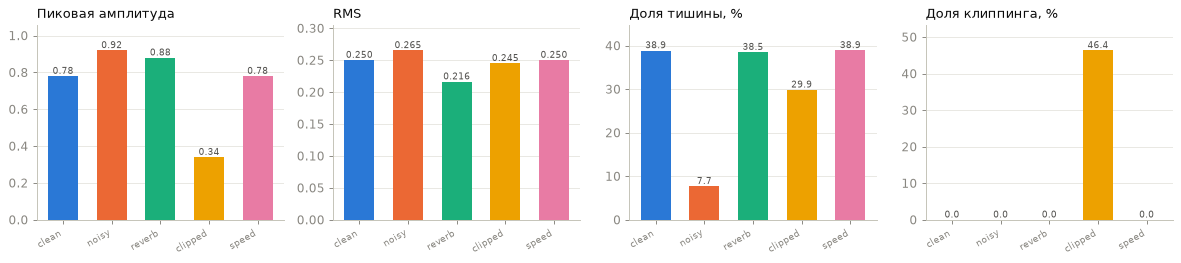

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
panels = [
    ("Пиковая амплитуда", [summary[k]["peak_amplitude"] for k in KEYS], "{:.2f}"),
    ("RMS", [summary[k]["rms"] for k in KEYS], "{:.3f}"),
    ("Доля тишины, %", [summary[k]["silence_fraction"] * 100 for k in KEYS], "{:.1f}"),
    ("Доля клиппинга, %", [summary[k]["clipping_fraction"] * 100 for k in KEYS], "{:.1f}"),
]
for ax, (title, vals, fmt) in zip(axes, panels):
    bars = ax.bar(range(5), vals, color=[COLOR[k] for k in KEYS], width=0.62)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v), ha="center", va="bottom", fontsize=8, color=INK2)
    ax.set_title(title, loc="left")
    ax.set_xticks(range(5))
    ax.set_xticklabels(["clean", "noisy", "reverb", "clipped", "speed"], rotation=30, ha="right", fontsize=8)
    ax.grid(True, axis="y")
    ax.set_axisbelow(True)
    ax.margins(y=0.15)
fig.tight_layout()
plt.show()

### Ответы на вопросы Части B

**1. У какого файла доля клиппинга ненулевая или необычно высокая? Почему?**
У **`clipped`** - **46.4 %** отсчётов лежат на выше потолка (≥ 0.98 · пик). У остальных файлов 0.001–0.011 % - это единичные отсчёты рядом с максимумом обычной (не обрезанной) волны, а не клиппинг. Причина - функция `add_clipping`: сигнал усиливается в 2.4 раза и жёстко ограничивается `np.clip(..., −0.34, +0.34)`, поэтому все вершины, вышедшие за порог, превращаются в плоские.
*Нюанс метрики:* порог берётся от **наблюдаемого** пика, т. е. метрика ловит плато на любом уровне (clipped здесь обрезан на 0.34, а не на 1.0). Зато чистый файл, пик-нормализованный до 
0.78, клиппированным не считается - и правильно.

**2. У какого файла самая короткая длительность? Почему?**
У **`speed_perturbed`** - 4.522 с против 5.200 с у остальных (5.2 / 4.522 = 1.15). `speed_perturb` делает `resample_poly(audio, 100, 115)`: число отсчётов уменьшается в 1.15 раза, а частота дискретизации в заголовке остаётся 16 кГц.

**3. Почему доля тишины может быть важна для ASR на длинных записях?**
* *Ресурсы:* на длинных записях тишины много; её не нужно прогонять через дорогую акустическую модель - сначала VAD / сегментация.
* *Качество:* на тишине и шуме особенно склонны выдумывать текст (галлюцинации, повторы) end-to-end модели типа Whisper; ложные вставки растут именно на пустых участках.
* *Сегментация и тайм-коды:* границы фраз, чанкинг, привязка субтитров строятся по паузам.
* *Диагностика записи:* ~100 % тишины - выключенный микрофон, ~0 % при непрерывном фоне - шум/музыка/плохая запись.

**Наблюдение по самой метрике.** Простой порог 2 % от пика не идеален: у `noisy` доля тишины всего **7.7 %** против **38.9 %** у `clean` - шум поднял пол выше порога, и паузы перестали считаться тишиной. У `clipped` - 29.9 %: пик срезан до 0.34, порог упал с 0.0156 до 0.0068, и усиленный в 2.4 раза шум пауз частично оказался выше него. Для настоящего VAD нужна энергия **относительно оценки шумового пола** или обученная модель.

**Проверка ожиданий Части A.** Самая высокая RMS действительно у `noisy` (0.265 против 0.250 у clean).

---
## Часть C - Волновая форма

Сначала целиком (серой полосой отмечено окно увеличения 0.5–0.6 с), затем фрагмент в 100 мс.

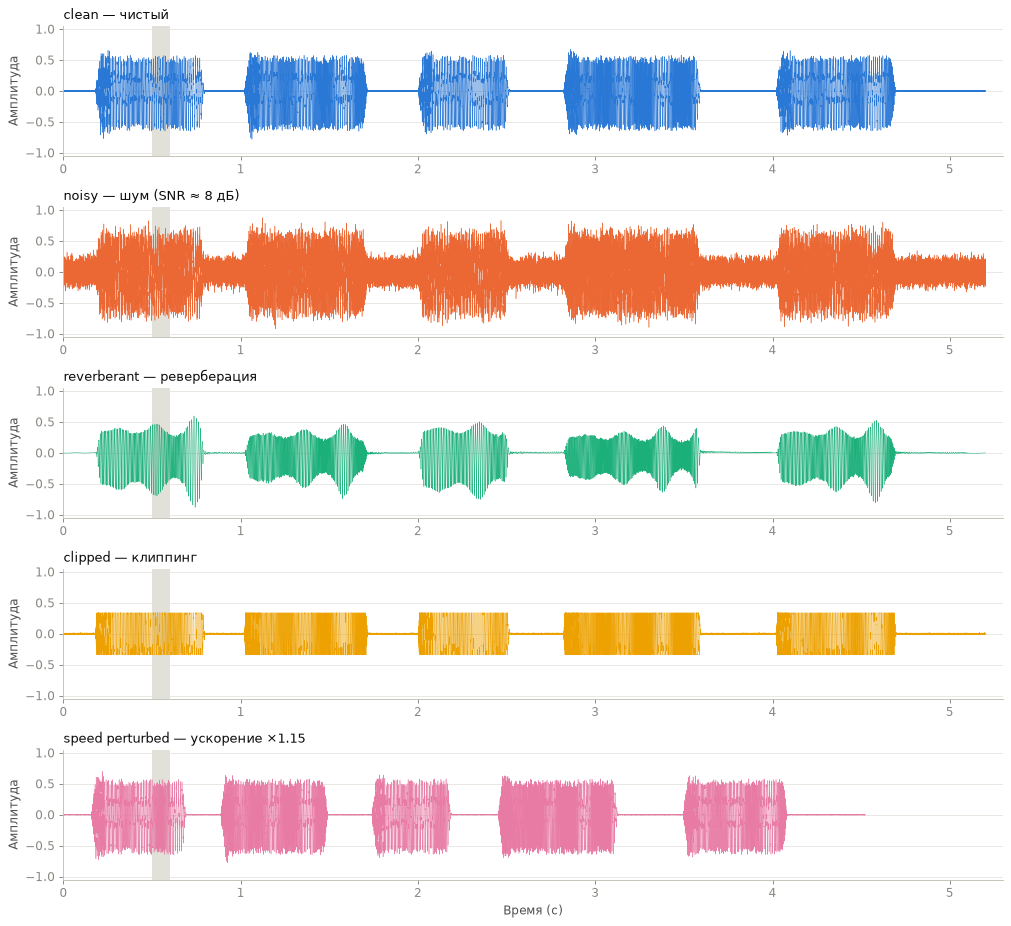

In [31]:
fig, axes = plt.subplots(5, 1, figsize=(12, 11), sharey=True)
for ax, key in zip(axes, KEYS):
    x = audio[key]
    ax.axvspan(0.5, 0.6, color=GRID, lw=0)
    ax.plot(np.arange(len(x)) / sr, x, lw=0.4, color=COLOR[key])
    ax.set_xlim(0, 5.3)
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel("Амплитуда")
    ax.set_title(LABEL[key], loc="left")
    ax.grid(True, axis="y")
axes[-1].set_xlabel("Время (с)")
fig.tight_layout()
plt.show()

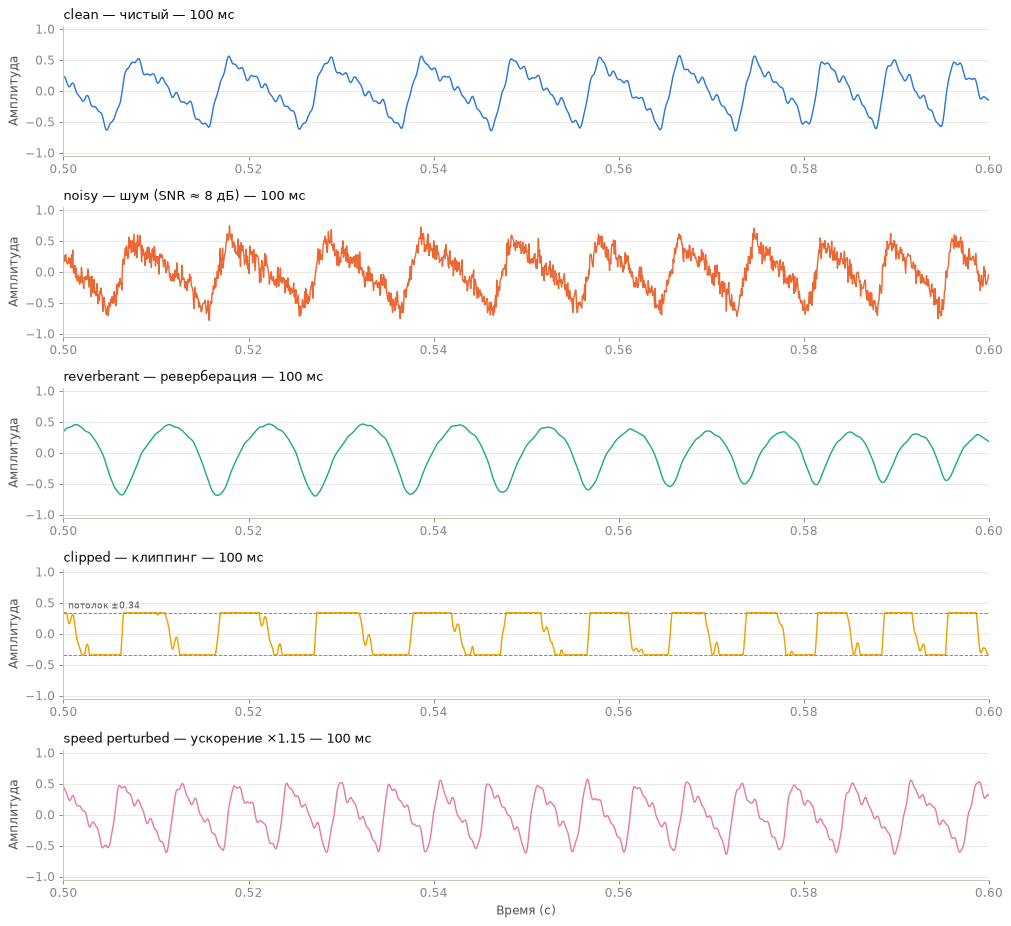

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 11), sharey=True)
for ax, key in zip(axes, KEYS):
    x = audio[key]
    i0, i1 = int(0.5 * sr), int(0.6 * sr)
    ax.plot(np.arange(i0, i1) / sr, x[i0:i1], color=COLOR[key], lw=1.2)
    if key == "clipped":                                  # потолок обрезки
        pk = summary[key]["peak_amplitude"]
        ax.axhline(pk, color=MUTED, ls="--", lw=0.8)
        ax.axhline(-pk, color=MUTED, ls="--", lw=0.8)
        ax.text(0.5005, pk + 0.07, f"потолок ±{pk:.2f}", fontsize=8, color=INK2)
    ax.set_xlim(0.5, 0.6)
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel("Амплитуда")
    ax.set_title(LABEL[key] + " - 100 мс", loc="left")
    ax.grid(True, axis="y")
axes[-1].set_xlabel("Время (с)")
fig.tight_layout()
plt.show()

Клиппинг хорошо виден и в **гистограмме значений отсчётов**: у обрезанного файла огромный пик ровно на уровне потолка (простой автоматический детектор клиппинга).

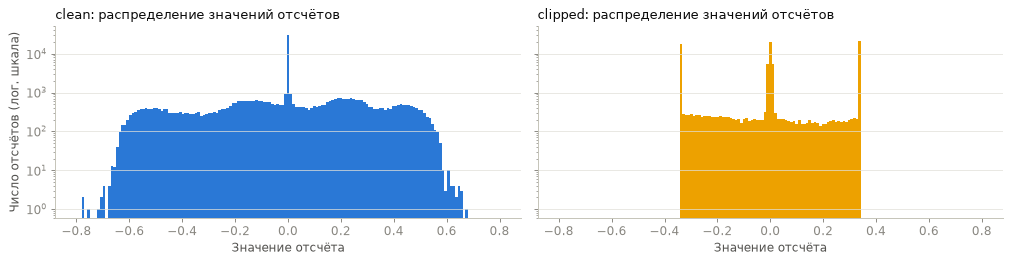

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), sharey=True)
for ax, key in zip(axes, ["clean", "clipped"]):
    ax.hist(audio[key], bins=161, range=(-0.8, 0.8), color=COLOR[key], log=True)
    ax.set_title(f"{SHORT[key]}: распределение значений отсчётов", loc="left")
    ax.set_xlabel("Значение отсчёта")
    ax.grid(True, axis="y")
axes[0].set_ylabel("Число отсчётов (лог. шкала)")
fig.tight_layout()
plt.show()

### Ответы на вопросы Части C

**1. Какое искажение легче всего увидеть на волновой форме?**
**Клиппинг**: огибающая упирается в потолок, а на 100-мс фрагменте у `clipped` вместо гладких периодов видны плоские площадки на ±0.34. Шум тоже заметен - паузы перестают быть нулевыми (RMS пола ≈ 0.10 против ≈ 0.002 у clean, т. е. примерно на 33 дБ выше), - но форму отдельного периода он почти не меняет. **Реверберацию и ускорение по волновой форме различить трудно**: у `reverberant` лишь слегка «плывёт» огибающая и появляются хвосты, у `speed perturbed` форма та же, просто всё сжато по времени.

**2. Как выглядит клиппинг?**
Горизонтальные полки на постоянном уровне ±порог, вершины периодов срезаны, форма близка к трапеции/прямоугольнику. Количественно: 46 % отсчётов на потолке, на гистограмме - огромный пик в ±0.34, crest factor (пик/RMS) падает с **3.12** у clean до **1.39** у clipped. Срез - нелинейное искажение, которое добавляет высокочастотные гармоники (доля энергии 4–8 кГц выросла с 0.19 % до 0.36 %, см. Часть D).

**3. Почему одной амплитуды может быть недостаточно, чтобы понять содержание речи?**
Волновая форма говорит, *сколько* энергии в каждый момент, но не *на каких частотах*. Содержание речи закодировано в спектральной огибающей (форманты) и быстрых спектральных переходах: две гласные одинаковой громкости выглядят на осциллограмме почти одинаково (на 100 мс видно ~10 периодов основного тона ≈ 100 Гц, но не видно, какой это звук). Кроме того, амплитуда зависит от усиления микрофона и расстояния до него, а сумма речь + шум на осциллограмме не разделяется.

---
## Часть D - Лог-спектрограмма STFT

STFT: режем сигнал на перекрывающиеся окна (25 мс, шаг 10 мс), к каждому применяем окно Ханна и FFT. Для 5.2 с получаем матрицу **(n_fft/2 + 1) × число фреймов**.

STFT clean: (201, 521) = (400//2+1 = 201 частотных бинов) x (521 фреймов); комплексная матрица complex64


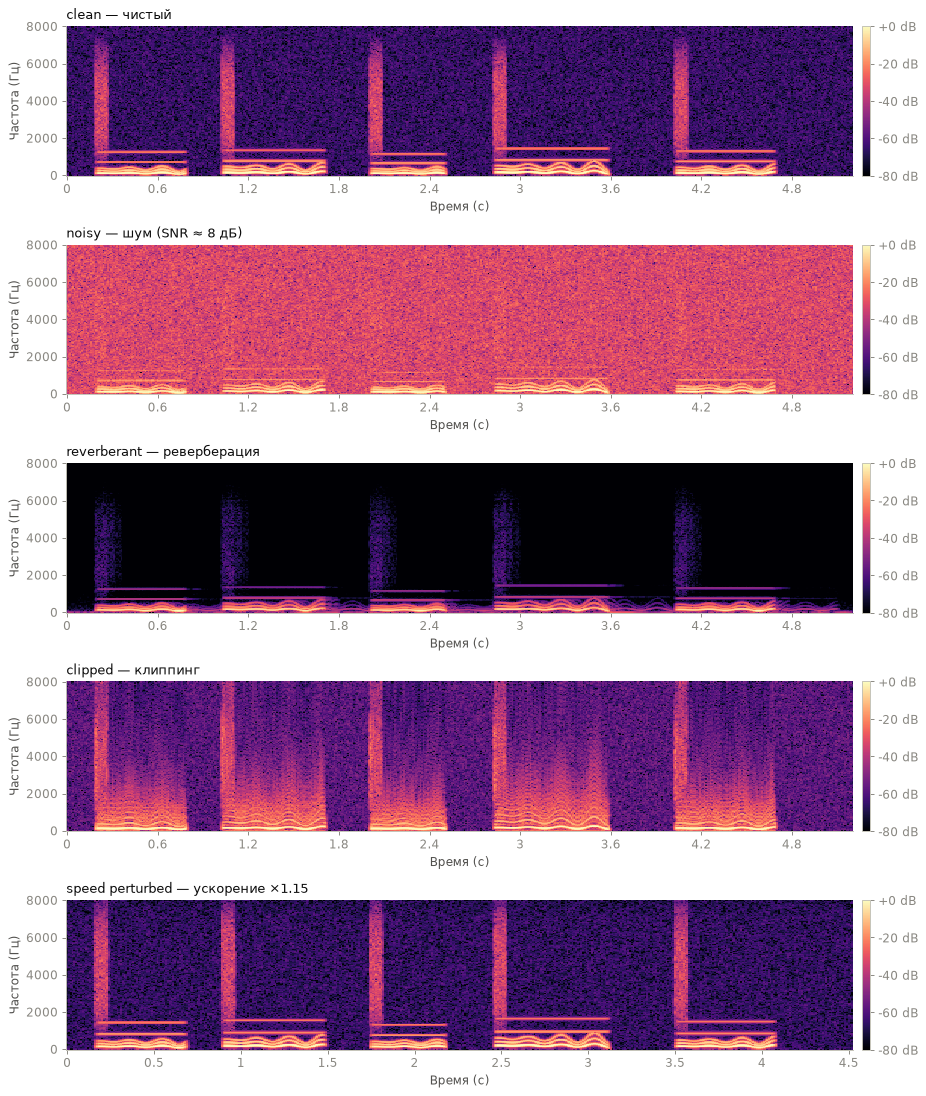

In [34]:
stft_db = {}
for key in KEYS:
    S = librosa.stft(audio[key], n_fft=lab.N_FFT, hop_length=lab.HOP_LENGTH, win_length=lab.WIN_LENGTH)
    stft_db[key] = librosa.amplitude_to_db(np.abs(S), ref=np.max)     # дБ относительно максимума файла
    if key == "clean":
        print(f"STFT clean: {S.shape} = ({lab.N_FFT}//2+1 = {lab.N_FFT // 2 + 1} частотных бинов) x "
              f"({1 + len(audio[key]) // lab.HOP_LENGTH} фреймов); комплексная матрица {S.dtype}")

fig, axes = plt.subplots(5, 1, figsize=(12, 13))
for ax, key in zip(axes, KEYS):
    img = librosa.display.specshow(stft_db[key], sr=sr, hop_length=lab.HOP_LENGTH, x_axis="time", y_axis="hz",
                                   ax=ax, cmap="magma", vmin=-80, vmax=0)
    ax.set_title(LABEL[key], loc="left")
    ax.set_xlabel("Время (с)")
    ax.set_ylabel("Частота (Гц)")
    fig.colorbar(img, ax=ax, format="%+2.0f dB", pad=0.01)
fig.tight_layout()
plt.show()

Цвет на спектрограммах нормирован на максимум **своего** файла, поэтому абсолютный уровень шума в сравнении не виден. Чтобы сравнить файлы честно, посмотрим на **средний спектр** (без пофайловой нормировки): как распределена энергия по частотам.

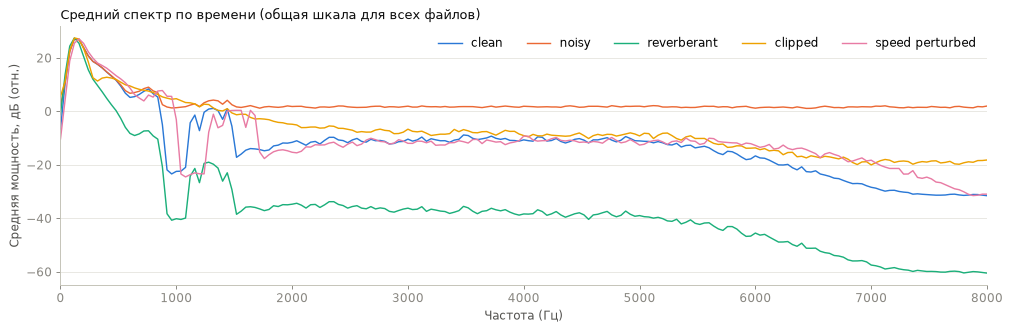

| Файл | Уровень в паузе 0.82–1.00 с отн. RMS сегмента, дБ |
|---|---|
| clean | -43.3 |
| reverberant | -31.3 |
| noisy | -10.8 |
| clipped | -35.5 |

In [35]:
freqs = librosa.fft_frequencies(sr=sr, n_fft=lab.N_FFT)
fig, ax = plt.subplots(figsize=(12, 4))
for key in KEYS:
    P = np.abs(librosa.stft(audio[key], n_fft=lab.N_FFT, hop_length=lab.HOP_LENGTH, win_length=lab.WIN_LENGTH)) ** 2
    ax.plot(freqs, 10 * np.log10(P.mean(axis=1) + 1e-12), color=COLOR[key], label=SHORT[key], lw=1.2)
ax.set_xlim(0, 8000)
ax.set_xlabel("Частота (Гц)")
ax.set_ylabel("Средняя мощность, дБ (отн.)")
ax.set_title("Средний спектр по времени (общая шкала для всех файлов)", loc="left")
ax.grid(True, axis="y")
ax.legend(frameon=False, ncol=5, loc="upper right")
fig.tight_layout()
plt.show()

# хвост реверберации: уровень в паузе 0.82–1.00 с (после 1-го сегмента) относительно RMS самого сегмента
def tail_db(x):
    return 20 * np.log10(rms(x[int(0.82 * sr): int(1.00 * sr)]) / rms(x[int(0.3 * sr): int(0.7 * sr)]))

for key in KEYS:
    metrics[key]["tail_db"] = tail_db(audio[key])
md_table(["Файл", "Уровень в паузе 0.82–1.00 с отн. RMS сегмента, дБ"],
         [[SHORT[k], f"{metrics[k]['tail_db']:.1f}"] for k in ["clean", "reverberant", "noisy", "clipped"]])

### Ответы на вопросы Части D

**1. В каком файле больше всего широкополосной высокочастотной энергии?**
В **`noisy`**: белый шум равномерно заполняет всю плоскость (время х частота), включая паузы. В полосе 4–8 кГц у него **7.0 %** энергии против **0.19 %** у clean (в 37 раз больше), центроид спектра 3131 Гц против 1859 Гц, а на среднем спектре его ВЧ-пол лежит примерно на 10–30 дБ выше, чем у clean. Узнаваемая структура остаётся только у сильных низкочастотных гармоник и формантных линий (< 1.5 кГц). У `clipped` ВЧ-энергия тоже выросла (0.36 % против 0.19 %) - из-за гармоник нелинейного искажения.

**2. Как реверберация меняет time-frequency паттерн?**
* **Размазывание во времени.** После конца каждого voiced-сегмента энергия не пропадает, а затухает около 0.3–0.4 с: на спектрограмме у каждого сегмента появляется хвост (в паузе после сегмента уровень ≈ −31 дБ от уровня сегмента против ≈ −43 дБ у clean; у noisy −11 дБ - но это не хвост, а постоянный шумовой фон). Паузы перестают быть пустыми, границы звуков и слогов размыты, хвост предыдущего звука накладывается на следующий.
* **Особенность этого синтетического примера.** Импульсная характеристика из `add_reverb` целиком положительна (затухающая экспонента), а значит работает ещё и как **ФНЧ**: коэффициент передачи на 1 кГц на ≈ 55 дБ ниже, чем на нуле. Поэтому у `reverberant` почти исчезает высокочастотный всплеск и центроид падает до ≈ 317 Гц.

**3. Почему шум может вызывать замены или удаления в ASR?**
* **Маскирование.** Слабые, но информативные звуки оказываются ниже уровня шума и исчезают -> **удаления** (или замена слова близким по звучанию).
* **Смещение признаков.** Шум меняет спектр *всех* фреймов (центроид 1859 → 3131 Гц), т. е. акустическая модель видит распределение, которого не было в обучении (domain mismatch)
* **Шум в паузах** может приниматься за речь (ошибки VAD, ложные короткие слова) -> **вставки** и галлюцинации.

**Проверка ожидания Части A.** Самые размытые переходы действительно у `reverberant`: хвосты после сегментов хорошо видны на спектрограмме выше.

---
## Часть E - Log-Mel-спектрограмма

Log-Mel получается из спектра мощности STFT так:

1. умножаем спектр мощности на **банк из 80 треугольных фильтров**, равномерно расположенных по шкале mel;
2. берём **логарифм** (в дБ).

$$ m = 2595\,\log_{10}\!\left(1 + \frac{f}{700}\right) \quad\text{(HTK-формула; librosa по умолчанию использует близкую шкалу Slaney)} $$

log-Mel clean: (80, 521) (80 mel-полос x фреймов); STFT был (201, 521)


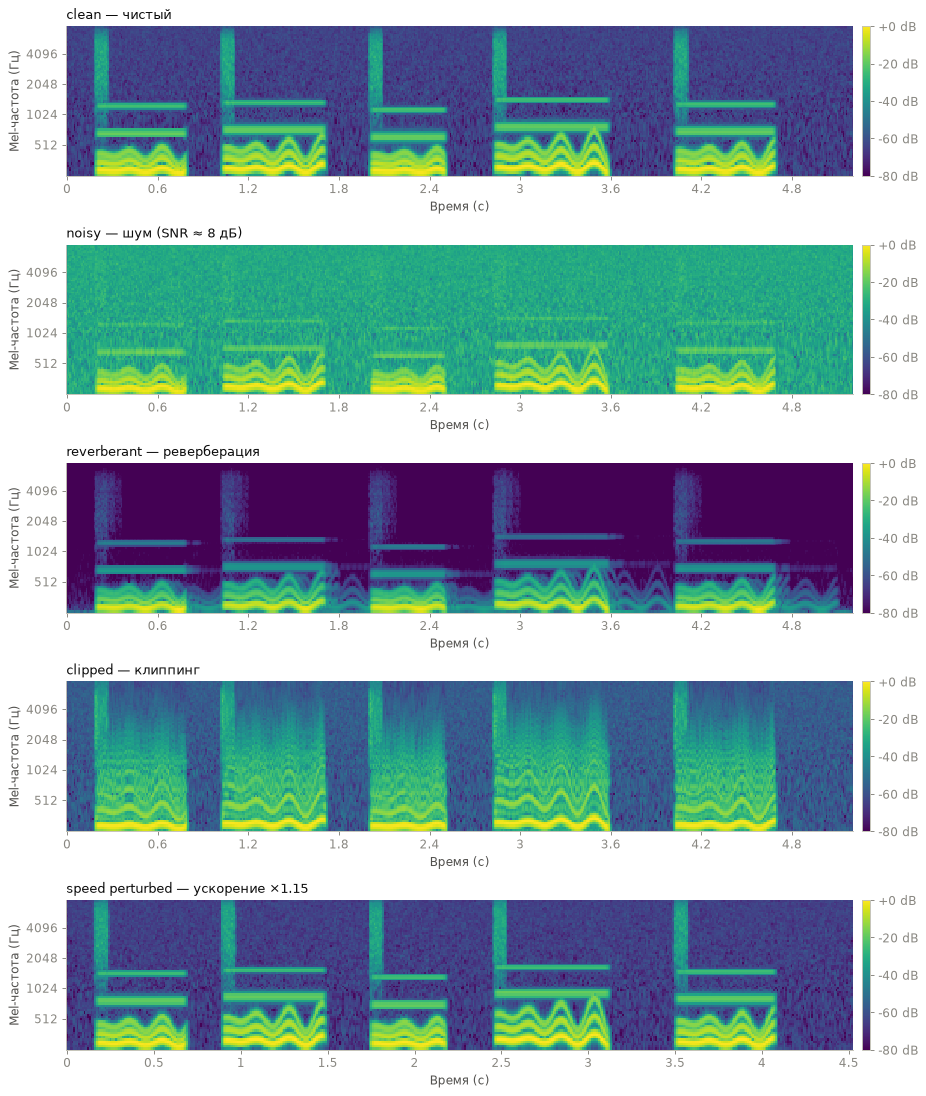

In [36]:
log_mel = {key: lab.compute_log_mel(audio[key], sr) for key in KEYS}     # (80, фреймы), дБ отн. максимума
print("log-Mel clean:", log_mel["clean"].shape, "(80 mel-полос x фреймов); STFT был", stft_db["clean"].shape)

fig, axes = plt.subplots(5, 1, figsize=(12, 13))
for ax, key in zip(axes, KEYS):
    img = librosa.display.specshow(log_mel[key], sr=sr, hop_length=lab.HOP_LENGTH, x_axis="time", y_axis="mel",
                                   fmin=lab.FMIN, fmax=lab.FMAX, ax=ax, cmap="viridis", vmin=-80, vmax=0)
    ax.set_title(LABEL[key], loc="left")
    ax.set_xlabel("Время (с)")
    ax.set_ylabel("Mel-частота (Гц)")
    fig.colorbar(img, ax=ax, format="%+2.0f dB", pad=0.01)
fig.tight_layout()
plt.show()

Как выглядит сам **банк фильтров**:

форма банка фильтров: (80, 201)
бинов FFT под фильтром: нижние 5 полос = [2, 2, 2, 2, 1], верхние 5 полос = [12, 12, 13, 14, 13]


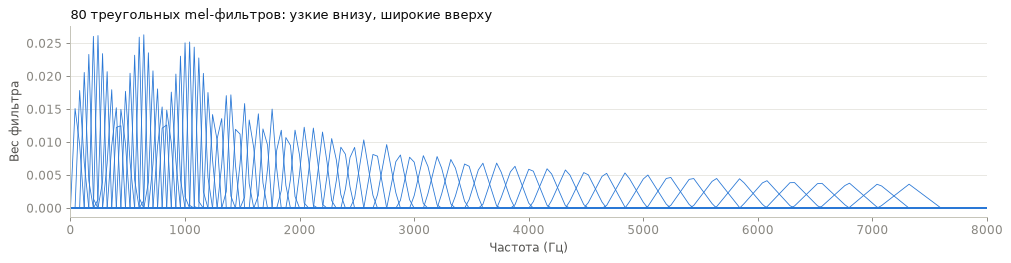

In [37]:
fb = librosa.filters.mel(sr=sr, n_fft=lab.N_FFT, n_mels=lab.N_MELS, fmin=lab.FMIN, fmax=lab.FMAX)   # (80, 201)
bins_per_band = (fb > 0).sum(axis=1)
print("форма банка фильтров:", fb.shape)
print(f"бинов FFT под фильтром: нижние 5 полос = {bins_per_band[:5].tolist()}, верхние 5 полос = {bins_per_band[-5:].tolist()}")

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(freqs, fb.T, color=COLOR["clean"], lw=0.7)
ax.set_xlim(0, 8000)
ax.set_xlabel("Частота (Гц)")
ax.set_ylabel("Вес фильтра")
ax.set_title("80 треугольных mel-фильтров: узкие внизу, широкие вверху", loc="left")
ax.grid(True, axis="y")
fig.tight_layout()
plt.show()

### Ответы на вопросы Части E

**1. Какую информацию легче увидеть на log-Mel, чем на волновой форме?**
Распределение энергии **по частотам и во времени**: где находятся гармоники основного тона (линии с вибрато у нижних полос) и формантные полосы около 0.7 и 1.25 кГц, где начинаются и заканчиваются voiced-сегменты, где паузы, насколько высок шумовой пол и на каких частотах он лежит (у `noisy` - равномерный фон выше ~1 кГц), где хвосты реверберации. Волновая форма смешивает все частоты в одну кривую и этого не показывает.

**2. Какая информация теряется или сжимается по сравнению с линейной STFT?**
* *Разрешение по частоте на высоких частотах:* вместо 201 линейных бинов - 80 полос; под нижними фильтрами 1–2 бина FFT, под верхними - 12–14 бинов, т. е. отдельные гармоники выше ~1–2 кГц уже не разрешаются, а всплеск 1.8–5.5 кГц превращается в несколько широких полос.
* *Фаза* (log-Mel строится по модулю), поэтому по log-Mel нельзя точно восстановить сигнал.
* *Края диапазона:* частоты < 20 Гц и > 7.6 кГц отрезаны параметрами `fmin/fmax`.
* Вместо точного спектра остаётся сглаженная огибающая в полосах.

**3. Почему логарифмические энергии полезны для речи?**
* Слух воспринимает громкость примерно логарифмически; в децибелах признаки ближе к восприятию.
* **Динамический диапазон** речи огромен (громкие гласные против тихих согласных - десятки дБ); в линейной шкале всё определяют несколько самых громких компонент, в логарифмической слабые, но важные звуки остаются видимыми.
* Умножение (усиление микрофона, свойства канала) превращается в **сложение константы**, которую легко убрать нормализацией (CMN/CMVN).
* Распределение значений становится ближе к гауссовскому - удобнее для нейросети и для GMM.

---
## Часть F - MFCC

MFCC = log-Mel → **дискретное косинусное преобразование (DCT-II)** по оси частот → первые 13 коэффициентов. Убедимся, что именно это делает `librosa.feature.mfcc`: посчитаем DCT вручную и сравним.

MFCC clean: (13, 521) (13 коэффициентов x фреймов)
max |ручной DCT - librosa.feature.mfcc| = 0.0


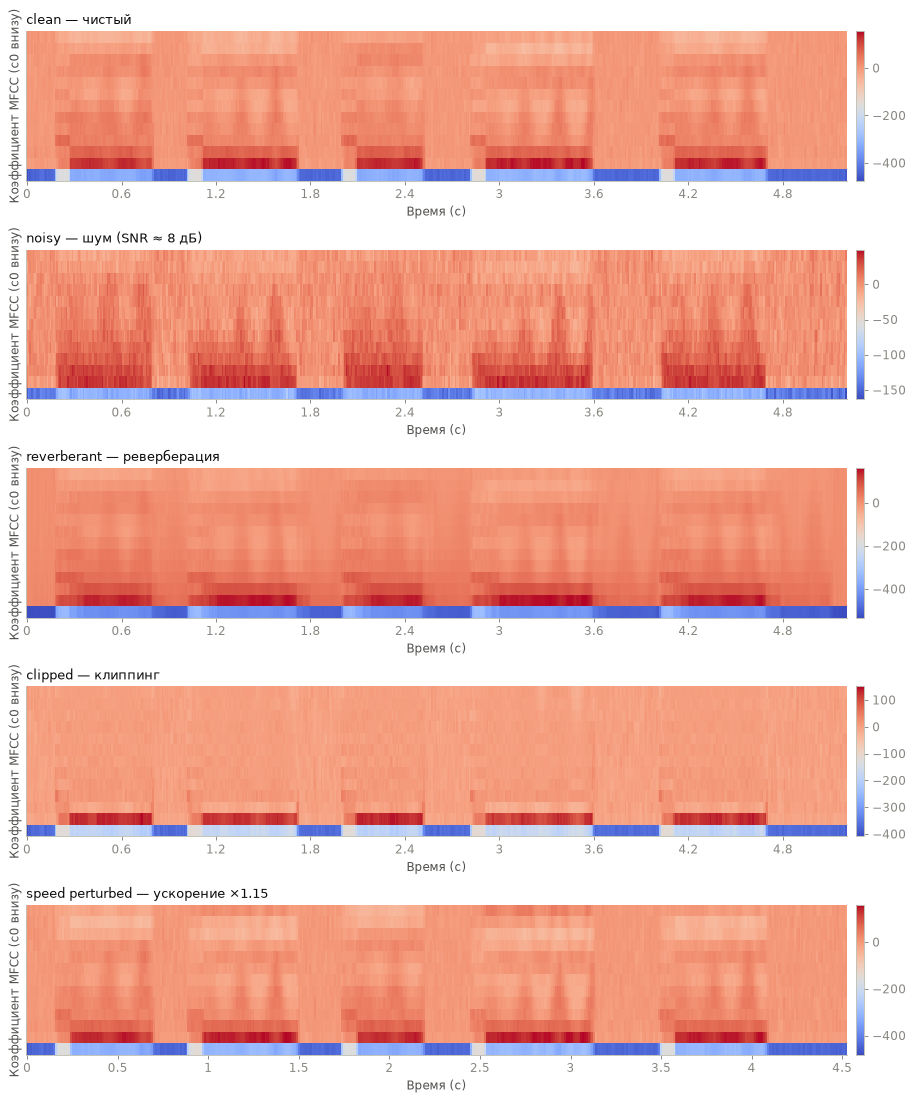

In [ ]:
import scipy


def mel_power(x):
    return librosa.feature.melspectrogram(y=x, sr=sr, n_fft=lab.N_FFT, hop_length=lab.HOP_LENGTH, win_length=lab.WIN_LENGTH,
                                          n_mels=lab.N_MELS, fmin=lab.FMIN, fmax=lab.FMAX, power=2.0)


x = audio["clean"]
logmel_db = librosa.power_to_db(mel_power(x))                                    # ref=1.0, top_db=80
mfcc_manual = scipy.fft.dct(logmel_db, type=2, axis=0, norm="ortho")[: lab.N_MFCC]
mfcc_lib = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=lab.N_MFCC, n_fft=lab.N_FFT, hop_length=lab.HOP_LENGTH,
                                win_length=lab.WIN_LENGTH, n_mels=lab.N_MELS, fmin=lab.FMIN, fmax=lab.FMAX)
mfcc_diff = float(np.abs(mfcc_manual - mfcc_lib).max())
print("MFCC clean:", mfcc_lib.shape, "(13 коэффициентов x фреймов)")
print("max |ручной DCT - librosa.feature.mfcc| =", mfcc_diff)

mfcc = {key: librosa.feature.mfcc(y=audio[key], sr=sr, n_mfcc=lab.N_MFCC, n_fft=lab.N_FFT, hop_length=lab.HOP_LENGTH,
                                  win_length=lab.WIN_LENGTH, n_mels=lab.N_MELS, fmin=lab.FMIN, fmax=lab.FMAX)
        for key in KEYS}

fig, axes = plt.subplots(5, 1, figsize=(12, 13))
for ax, key in zip(axes, KEYS):
    img = librosa.display.specshow(mfcc[key], sr=sr, hop_length=lab.HOP_LENGTH, x_axis="time", ax=ax, cmap="coolwarm")
    ax.set_title(LABEL[key], loc="left")
    ax.set_xlabel("Время (с)")
    ax.set_ylabel("Коэффициент MFCC (c0 внизу)")
    fig.colorbar(img, ax=ax, pad=0.01)
fig.tight_layout()
plt.show()

Коэффициент **c0** равен √80 · (среднее значение log-Mel по полосам), т. е. отражает общий уровень кадра; он в несколько раз больше остальных и забивает цветовую шкалу. Если убрать c0 и сравнить файлы на **одной** шкале, видно, как сильно шум и реверберация меняют сами MFCC:

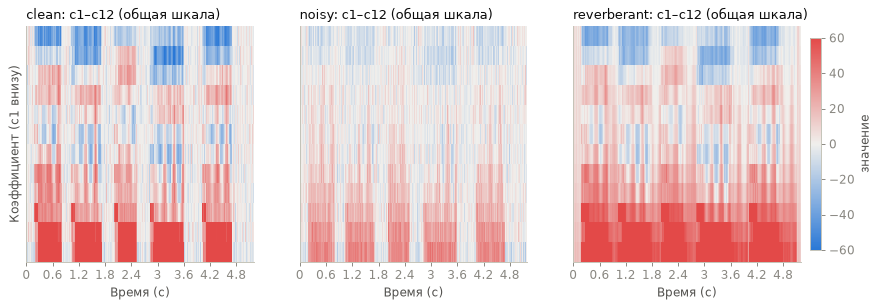

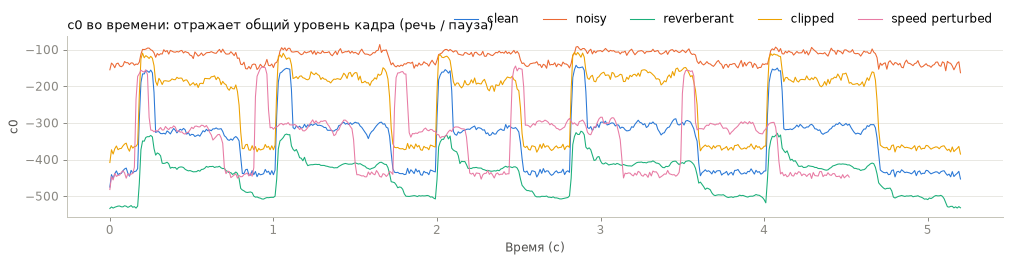

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, key in zip(axes, ["clean", "noisy", "reverberant"]):
    img = librosa.display.specshow(mfcc[key][1:], sr=sr, hop_length=lab.HOP_LENGTH, x_axis="time", ax=ax,
                                   cmap=DIV_CMAP, vmin=-60, vmax=60)
    ax.set_title(f"{SHORT[key]}: c1–c12 (общая шкала)", loc="left")
    ax.set_xlabel("Время (с)")
axes[0].set_ylabel("Коэффициент (c1 внизу)")
fig.colorbar(img, ax=axes, shrink=0.9, pad=0.01, label="значение")
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.2))
for key in KEYS:
    t = librosa.frames_to_time(np.arange(mfcc[key].shape[1]), sr=sr, hop_length=lab.HOP_LENGTH)
    ax.plot(t, mfcc[key][0], color=COLOR[key], label=SHORT[key], lw=0.9)
ax.set_xlabel("Время (с)")
ax.set_ylabel("c0")
ax.set_title("c0 во времени: отражает общий уровень кадра (речь / пауза)", loc="left")
ax.grid(True, axis="y")
ax.legend(frameon=False, ncol=5, loc="lower right", bbox_to_anchor=(1, 1.0))
fig.tight_layout()
plt.show()

### Ответы на вопросы Части F

**1. Чем визуально графики MFCC отличаются от log-Mel?**
* Строк всего **13** вместо 80, и по вертикали теперь не частота, а **номер кепстрального коэффициента**: гармоники и форманты в виде отчётливых линий исчезли - остались блоки в моменты речи.
* c0 (среднее log-Mel по полосам ≈ общий уровень кадра) в несколько раз больше остальных коэффициентов и доминирует на цветовой шкале.
* Картинка менее наглядна для человека, но коэффициенты **слабо коррелированы** между собой. Шум и реверберация меняют MFCC по-разному: при шуме (`noisy`) контраст речь - пауза в c1–c12 заметно падает, значения сжимаются к нулю, а разброс от кадра к кадру растёт; при реверберации возникает большой систематический сдвиг низких коэффициентов (изменился наклон спектра).

**2. Почему компактное представление может быть полезным?**
Меньше размерность (13 вместо 80 значит меньше вычислений, памяти и параметров модели); DCT **декоррелирует** признаки, что критично для классических GMM-HMM с диагональной ковариацией; низкие коэффициенты описывают **гладкую спектральную огибающую** (форму речевого тракта - фонетическое содержание) и отбрасывают тонкую гармоническую структуру (высоту тона); для малых датасетов меньшее число признаков - меньше риск переобучения.

**3. Почему современный нейросетевой ASR может предпочитать более богатые log-Mel признаки?**
DCT **выбрасывает информацию** (старшие коэффициенты, детали гармоник), а нейросеть способна сама научиться нужным преобразованиям и не нуждается в ручной декорреляции. Кроме того, у log-Mel сохраняется **локальность по частоте** (соседние полосы - соседние частоты), на чём построены свёрточные слои и аугментации вроде SpecAugment (маскирование полос частот); у MFCC ось астоты перемешана косинусным базисом. Ну и большие модели обучаются на огромных данных, где 80-мерный log-Mel (или сама волна) даёт более высокое качество, чем 13 MFCC.

---
## Часть G - Сравнение чистого и искажённого аудио

Штатный скрипт построил сводную картинку `feature_comparison_contact_sheet.png` (слева - волна, справа - log-Mel):

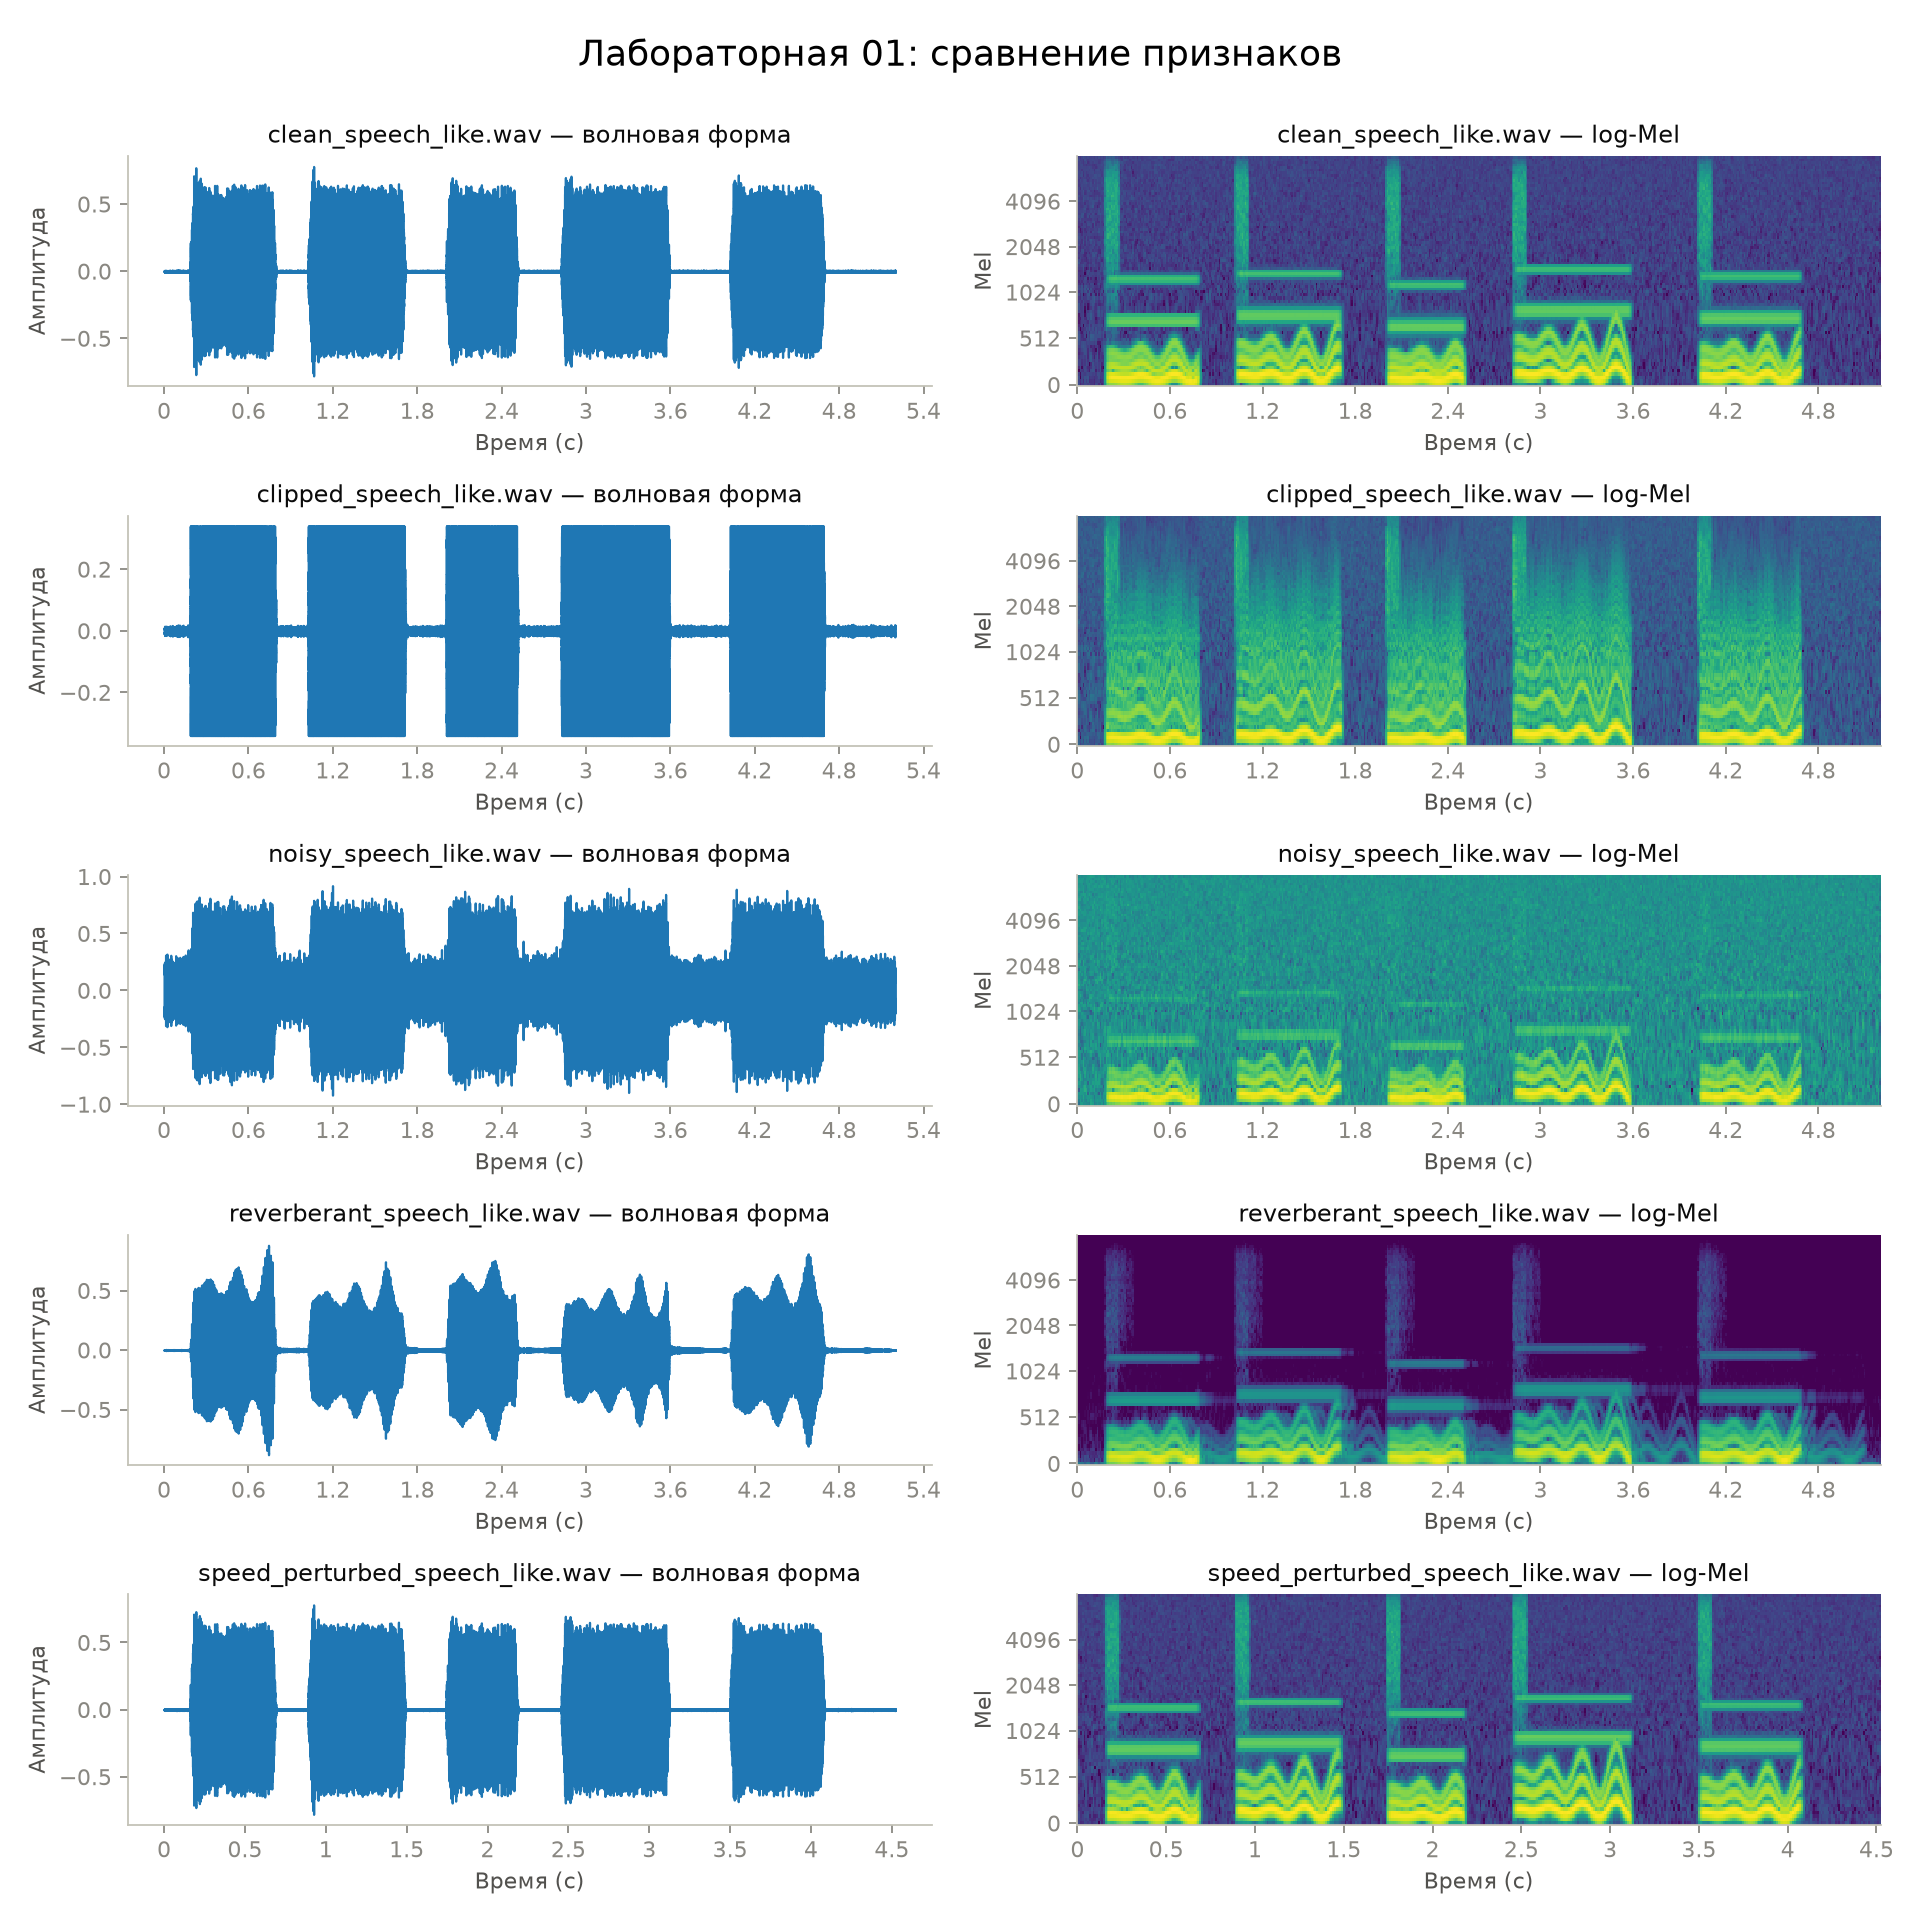

In [40]:
display(Image(filename=str(OUT_DIR / "feature_comparison_contact_sheet.png"), width=900))

Чтобы увидеть именно **что изменилось** относительно чистого сигнала, вычтем log-Mel чистого файла из log-Mel искажённых (на общей абсолютной дБ-шкале; красное - энергии стало больше, синее - меньше). Файлы пик-нормализованы по-разному (0.78/0.92/0.88/0.34), поэтому в разности есть и небольшая постоянная составляющая из-за разного усиления.

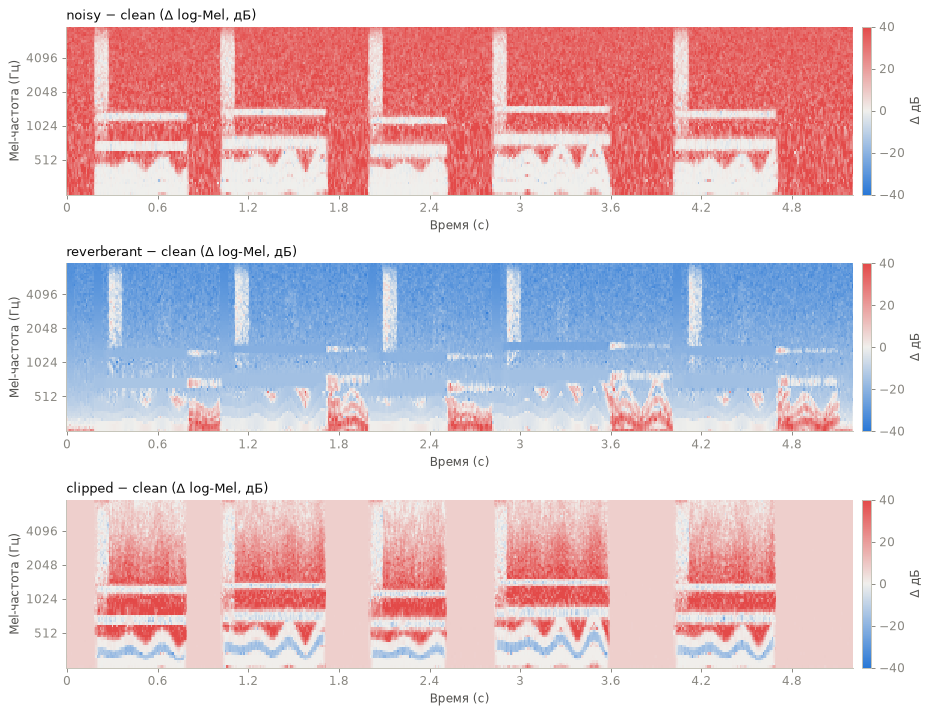

In [41]:
def logmel_abs(x):
    return librosa.power_to_db(mel_power(x), ref=1.0, top_db=None)


ref_db = logmel_abs(audio["clean"])
fig, axes = plt.subplots(3, 1, figsize=(12, 8.5))
for ax, key in zip(axes, ["noisy", "reverberant", "clipped"]):
    diff = logmel_abs(audio[key]) - ref_db
    img = librosa.display.specshow(diff, sr=sr, hop_length=lab.HOP_LENGTH, x_axis="time", y_axis="mel",
                                   fmin=lab.FMIN, fmax=lab.FMAX, ax=ax, cmap=DIV_CMAP, vmin=-40, vmax=40)
    ax.set_title(f"{SHORT[key]} − clean (Δ log-Mel, дБ)", loc="left")
    ax.set_xlabel("Время (с)")
    ax.set_ylabel("Mel-частота (Гц)")
    fig.colorbar(img, ax=ax, pad=0.01, label="Δ дБ")
fig.tight_layout()
plt.show()

Ускорение сравнить покадрово нельзя (другая длина), поэтому померим два числа: **во сколько раз сдвинулись моменты начала звуков** и **во сколько раз сдвинулись частоты** синтетических «формантных» линий (в `clean` это синусоиды 720 Гц и 1250 Гц в первом сегменте).

In [42]:
def onsets(x, thr=0.05):
    # Моменты, когда RMS-огибающая впервые превышает порог (начало звуков).
    r = librosa.feature.rms(y=x, frame_length=lab.WIN_LENGTH, hop_length=lab.HOP_LENGTH)[0]
    active = r > thr
    idx = np.flatnonzero(active[1:] & ~active[:-1]) + 1
    return librosa.frames_to_time(idx, sr=sr, hop_length=lab.HOP_LENGTH)


def spectral_peak(x, t0, t1, lo, hi):
    # Частота максимума спектра в окне [t0, t1] внутри полосы [lo, hi].
    seg = x[int(t0 * sr): int(t1 * sr)]
    n = 1 << 16
    spec = np.abs(np.fft.rfft(seg * np.hanning(len(seg)), n=n))
    f = np.fft.rfftfreq(n, 1 / sr)
    m = (f >= lo) & (f <= hi)
    return float(f[m][np.argmax(spec[m])])


speed = 1.15
on_c, on_s = onsets(audio["clean"]), onsets(audio["speed_perturbed"])
print("начала звуков clean, с:           ", np.round(on_c, 2))
print("начала звуков speed perturbed, с: ", np.round(on_s, 2))
print("отношение (clean / speed):        ", np.round(on_c / on_s, 3), "-> среднее", round(float(np.mean(on_c / on_s)), 3))
print("отношение длительностей:           ", round(len(audio["clean"]) / len(audio["speed_perturbed"]), 3))

f720_c = spectral_peak(audio["clean"], 0.22, 0.76, 650, 800)
f720_s = spectral_peak(audio["speed_perturbed"], 0.22 / speed, 0.76 / speed, 700, 900)
f1250_c = spectral_peak(audio["clean"], 0.22, 0.76, 1150, 1350)
f1250_s = spectral_peak(audio["speed_perturbed"], 0.22 / speed, 0.76 / speed, 1300, 1500)
print(f"линия ~720 Гц:  clean {f720_c:.0f} Гц -> speed {f720_s:.0f} Гц (x{f720_s / f720_c:.3f})")
print(f"линия ~1250 Гц: clean {f1250_c:.0f} Гц -> speed {f1250_s:.0f} Гц (x{f1250_s / f1250_c:.3f})")

начала звуков clean, с:            [0.19 1.03 2.01 2.82 4.03]
начала звуков speed perturbed, с:  [0.16 0.89 1.74 2.46 3.5 ]
отношение (clean / speed):         [1.188 1.157 1.155 1.146 1.151] -> среднее 1.16
отношение длительностей:            1.15
линия ~720 Гц:  clean 720 Гц -> speed 828 Гц (x1.150)
линия ~1250 Гц: clean 1250 Гц -> speed 1438 Гц (x1.150)


### Таблица Части G

| Искажение | Что изменилось в волновой форме? | Что изменилось в спектрограмме / log-Mel? | Возможный тип ошибки ASR |
|---|---|---|---|
| **Шум** (SNR ≈ 8 дБ) | Паузы заполнены шумом: RMS пола ≈ 0.10 вместо ≈ 0.002 (+33 дБ); огибающая речи «тонет», пик поднялся до 0.92; доля «тишины» упала с 38.9 % до 7.7 % | Равномерный широкополосный фон по всему времени и всем частотам (4–8 кГц: 7.0 % энергии против 0.19 %); паузы перестали быть тёмными; слабые ВЧ-всплески (согласные) замаскированы, устойчивыми остаются сильные НЧ-гармоники | **Замены и удаления** слабых звуков/слов; **вставки** и **галлюцинации** на шуме в паузах; **плохое определение границ речи** (VAD принимает шум за речь) |
| **Реверберация** | Огибающая «сглажена», после каждого сегмента остаётся хвост (≈ −31 дБ против −43 дБ у clean), паузы не нулевые; в этом примере форма периода плавнее (НЧ-фильтрация из-за положительной RIR) | **Размазывание по времени**: хвосты после сегментов, наложение предыдущего звука на следующий, размытые границы фонем; ВЧ-всплески почти исчезли (центроид 317 Гц) | **Замены/удаления** из-за смазанных переходов; **неверные временные метки** и границы речи; слипание соседних слов |
| **Клиппинг** | Плоские «полки» на ±0.34, 46 % отсчётов на потолке; crest factor 3.12 → 1.39; шум пауз усилен ×2.4 | Широкополосные гармоники искажения: «занавес» энергии над гармониками voiced-звуков, доля 4–8 кГц выросла в ≈ 1.9 раза; шумовой пол в паузах выше | **Замены** (признаки смещены, ложные ВЧ-компоненты), ошибки на согласных; потеря динамики/просодии → **ухудшение пунктуации и регистра** в downstream-обработке |
| **Ускорение** (×1.15) | Файл короче в 1.15 раза (4.52 с против 5.2 с), все события наступают раньше (в ≈ 1.15 раза; оценка по 10-мс фреймам даёт 1.16); форма периода та же | Всё **сжато по времени** на 15 % (453 фрейма вместо 521) и **сдвинуто вверх по частоте** на 15 %: линии 720 → 828 Гц, 1250 → 1437 Гц; основной тон выше | **Удаления** (на каждый звук приходится на 15 % меньше фреймов); **замены** гласных из-за сдвинутых формант; **неверные временные метки**, если их не пересчитали; рост WER на быстрой речи |

**Проверка ожидания Части A:** подтвердилось, что самое заметное искажение *формы волны* - клиппинг (Часть C), самая высокая RMS - у noisy (Часть B), самые размытые переходы - у reverberant (Часть D).

---
## Дополнительное задание - собственная запись

**test-my-voice.wav** - длительность 15.964 с, пик 0.206, RMS 0.0198, тишина 49.1 %, клиппинг 0.001 %, доля энергии 4–8 кГц 3.247 %

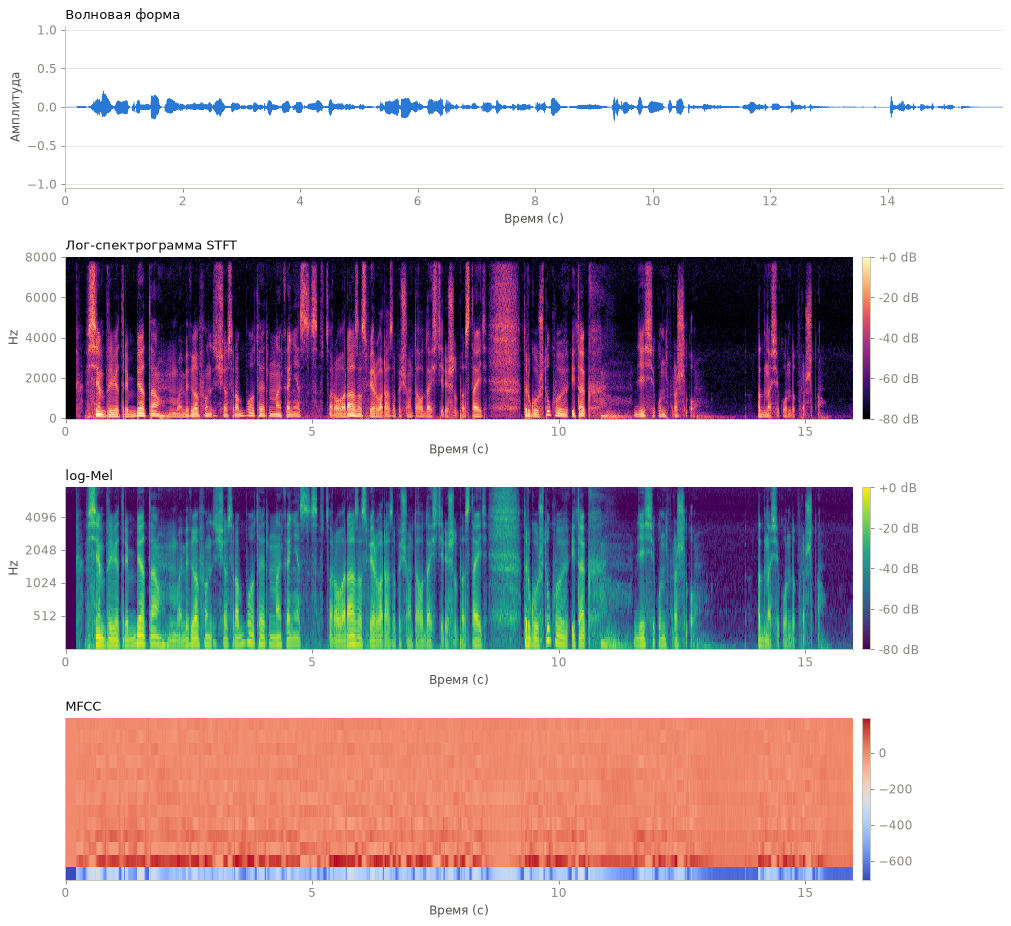

In [51]:
def inspect_file(path):
    # Статистика + волновая форма + STFT + log-Mel + MFCC для одного WAV.
    path = Path(path)
    x, sr_ = lab.load_audio(path)
    s = lab.summarize_audio(path.name, x, sr_)
    display(Markdown(
        f"**{path.name}** - длительность {s['duration_s']} с, пик {s['peak_amplitude']:.3f}, RMS {s['rms']:.4f}, "
        f"тишина {s['silence_fraction'] * 100:.1f} %, клиппинг {s['clipping_fraction'] * 100:.3f} %, "
        f"доля энергии 4–8 кГц {band_share(x, 4000, 8000) * 100:.3f} %"))
    display(Audio(x, rate=sr_, normalize=False))

    fig, axes = plt.subplots(4, 1, figsize=(12, 11))
    axes[0].plot(np.arange(len(x)) / sr_, x, lw=0.4, color=COLOR["clean"])
    axes[0].set_ylim(-1.05, 1.05); axes[0].set_xlim(0, len(x) / sr_)
    axes[0].set_title("Волновая форма", loc="left"); axes[0].set_ylabel("Амплитуда"); axes[0].grid(True, axis="y")
    S = librosa.amplitude_to_db(np.abs(librosa.stft(x, n_fft=lab.N_FFT, hop_length=lab.HOP_LENGTH, win_length=lab.WIN_LENGTH)), ref=np.max)
    img = librosa.display.specshow(S, sr=sr_, hop_length=lab.HOP_LENGTH, x_axis="time", y_axis="hz", ax=axes[1], cmap="magma", vmin=-80, vmax=0)
    axes[1].set_title("Лог-спектрограмма STFT", loc="left"); fig.colorbar(img, ax=axes[1], format="%+2.0f dB", pad=0.01)
    lm = lab.compute_log_mel(x, sr_)
    img = librosa.display.specshow(lm, sr=sr_, hop_length=lab.HOP_LENGTH, x_axis="time", y_axis="mel", fmin=lab.FMIN, fmax=lab.FMAX,
                                   ax=axes[2], cmap="viridis", vmin=-80, vmax=0)
    axes[2].set_title("log-Mel", loc="left"); fig.colorbar(img, ax=axes[2], format="%+2.0f dB", pad=0.01)
    mf = librosa.feature.mfcc(y=x, sr=sr_, n_mfcc=lab.N_MFCC, n_fft=lab.N_FFT, hop_length=lab.HOP_LENGTH,
                              win_length=lab.WIN_LENGTH, n_mels=lab.N_MELS, fmin=lab.FMIN, fmax=lab.FMAX)
    img = librosa.display.specshow(mf, sr=sr_, hop_length=lab.HOP_LENGTH, x_axis="time", ax=axes[3], cmap="coolwarm")
    axes[3].set_title("MFCC", loc="left"); fig.colorbar(img, ax=axes[3], pad=0.01)
    for ax in axes:
        ax.set_xlabel("Время (с)")
    fig.tight_layout()
    plt.show()


STANDARD_FILES = set(FNAME.values())
extra_files = sorted(p for p in WAV_DIR.glob("*.wav") if p.name not in STANDARD_FILES)
if extra_files:
    for p in extra_files:
        inspect_file(p)
else:
    print("Своих записей в data/wav пока нет. Положите туда WAV и запустите ячейку снова.")

скрипт показывает 49% тишины, но по кадрам тишины около 17%, потому что метрика считает отсчёты, а не речевые участки.

---
## Автоматическая проверка выводов

Все количественные утверждения из ответов выше собраны в проверках. Если параметры генерации поменяются, ячейка сразу покажет, какой вывод перестал выполняться.

In [52]:
dur = {k: summary[k]["duration_s"] for k in KEYS}
checks = {
    "A1/B: самая высокая RMS у noisy": max(KEYS, key=lambda k: summary[k]["rms"]) == "noisy",
    "B1: клиппинг > 40 % только у clipped": [k for k in KEYS if summary[k]["clipping_fraction"] > 0.4] == ["clipped"],
    "B1: у остальных клиппинг < 0.02 %": all(summary[k]["clipping_fraction"] < 2e-4 for k in KEYS if k != "clipped"),
    "B2: самая короткая - speed_perturbed": min(KEYS, key=lambda k: dur[k]) == "speed_perturbed",
    "B2: отношение длительностей ≈ 1.15": abs(dur["clean"] / dur["speed_perturbed"] - 1.15) < 0.01,
    "B3: шум снижает «тишину» (noisy < 10 %, clean > 35 %)": summary["noisy"]["silence_fraction"] < 0.10 < 0.35 < summary["clean"]["silence_fraction"],
    "C2: crest factor clipped < 1.5 < 3 < clean": metrics["clipped"]["crest"] < 1.5 and metrics["clean"]["crest"] > 3,
    "C1: пол шума noisy > 30 дБ выше clean": 20 * np.log10(metrics["noisy"]["floor_rms"] / metrics["clean"]["floor_rms"]) > 30,
    "D1: максимум доли 4–8 кГц у noisy (> 5 %)": max(KEYS, key=lambda k: metrics[k]["hf_share"]) == "noisy" and metrics["noisy"]["hf_share"] > 0.05,
    "D1: clipped имеет больше ВЧ, чем clean": metrics["clipped"]["hf_share"] > metrics["clean"]["hf_share"],
    "D2: хвост после сегмента у reverberant громче, чем у clean": metrics["reverberant"]["tail_db"] > metrics["clean"]["tail_db"] + 5,
    "D2: центроид reverberant < 500 Гц < clean": metrics["reverberant"]["centroid"] < 500 < metrics["clean"]["centroid"],
    "F: ручной DCT совпадает с librosa.mfcc": mfcc_diff < 1e-6,
    "G: ускорение сдвигает частоты в 1.15 раза": abs(f720_s / f720_c - 1.15) < 0.01 and abs(f1250_s / f1250_c - 1.15) < 0.01,
    "G: моменты начала звуков сжаты в ≈ 1.15 раза": abs(float(np.mean(on_c / on_s)) - 1.15) < 0.05,
}
for name, ok in checks.items():
    print(("✓ " if ok else "✗ ") + name)
assert all(checks.values()), "Какое-то утверждение из ответов не выполняется - перепроверьте текст!"
print("\nВсе проверки пройдены.")

✓ A1/B: самая высокая RMS у noisy
✓ B1: клиппинг > 40 % только у clipped
✓ B1: у остальных клиппинг < 0.02 %
✓ B2: самая короткая - speed_perturbed
✓ B2: отношение длительностей ≈ 1.15
✓ B3: шум снижает «тишину» (noisy < 10 %, clean > 35 %)
✓ C2: crest factor clipped < 1.5 < 3 < clean
✓ C1: пол шума noisy > 30 дБ выше clean
✓ D1: максимум доли 4–8 кГц у noisy (> 5 %)
✓ D1: clipped имеет больше ВЧ, чем clean
✓ D2: хвост после сегмента у reverberant громче, чем у clean
✓ D2: центроид reverberant < 500 Гц < clean
✓ F: ручной DCT совпадает с librosa.mfcc
✓ G: ускорение сдвигает частоты в 1.15 раза
✓ G: моменты начала звуков сжаты в ≈ 1.15 раза

Все проверки пройдены.


## Итоги

* **Аудио нужно осмотреть до ASR.** Пять простых чисел (длительность, пик, RMS, доля тишины, доля клиппинга) уже ловят клиппинг, пустые записи и неожиданную длительность; но они *не заменяют* графиков: например, порог тишины 2 % от пика ломается на шумной записи.

* **Волновая форма** лучше всего показывает клиппинг, паузы и огибающую; 
**STFT** - частотную структуру (гармоники, шум, хвосты реверберации); 
**log-Mel** - то же в компактном перцептивном виде, на котором работают нейросетевые ASR; 
**MFCC** - ещё более компактное декоррелированное представление классических систем.

* **Каждое искажение имеет свою характеристику:** 
шум - равномерный фон и поднятый пол пауз; 
реверберация - хвосты и размытые переходы; 
клиппинг - полки на волне и ВЧ-гармоники; 
ускорение - сжатие по времени и сдвиг частот вверх.
* **Связь с ошибками ASR:** шум это замены/удаления/вставки и  галлюцинации в паузах; реверберация это смазанные границы и временные метки; клиппинг это замены согласных; ускорение 
то удаления и замены гласных.

### Чек-лист для осмотра аудио перед ASR
1. частота дискретизации и число каналов совпадают с ожиданиями модели; 
2. длительность адекватная; 
3. пик и доля клиппинга; 
4. доля тишины и уровень шумового пола; 
5. нет ли обрезанного спектра (энергии выше 4 кГц) - признак узкополосного источника/кодека; 
6. на спектрограмме - хвосты реверберации, и/или гул на постоянной частоте; 
7. совпадают ли границы речи с ожидаемыми.